# Jaccard Similarity for Wikispeedia Next-Hop Prediction

Jacob Lehman, CSCI 4022 Final Project

In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")
TEXT_DIR = DATA_DIR / "plaintext_articles"

## Load links.tsv

In [3]:
links = pd.read_csv(
    DATA_DIR / "links.tsv",
    sep="\t",
    comment="#",
    names=["source", "target"],
)

print(links.shape)
links.head()

(119882, 2)


,source,target
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Bede
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Columba
2,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,D%C3%A1l_Riata
3,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Great_Britain
4,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Ireland


## Load articles.tsv

In [4]:
articles = pd.read_csv(
    DATA_DIR / "articles.tsv",
    sep="\t",
    comment="#",
    names=["article"],
)["article"].tolist()

print(f"{len(articles)} articles")
articles[:5]

4604 articles


['%C3%81ed%C3%A1n_mac_Gabr%C3%A1in',
 '%C3%85land',
 '%C3%89douard_Manet',
 '%C3%89ire',
 '%C3%93engus_I_of_the_Picts']

## Load paths_finished.tsv

In [5]:
paths_finished = pd.read_csv(
    DATA_DIR / "paths_finished.tsv",
    sep="\t",
    comment="#",
    names=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"],
)

print(paths_finished.shape)
paths_finished.head()

(51318, 5)


,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0


## Build neighbors dict

In [6]:
neighbors = links.groupby("source")["target"].apply(set).to_dict()

print(f"{len(neighbors)} articles have outgoing links")
print(f"Example: France -> {len(neighbors['France'])} neighbors")
list(neighbors["France"])[:5]

4587 articles have outgoing links
Example: France -> 85 neighbors


['Brussels', 'British_Empire', 'Brazil', 'Portuguese_language', 'River']

## Shingles function

In [7]:
def shingles(text: str, k: int = 3) -> set[str]:
    tokens = text.lower().split()
    return {" ".join(tokens[i:i + k]) for i in range(len(tokens) - k + 1)}

shingles("the quick brown fox", k=2)

{'brown fox', 'quick brown', 'the quick'}

## Build shingle sets for all articles

In [8]:
shingle_sets: dict[str, set[str]] = {}
skipped: list[str] = []

for article in articles:
    text_path = TEXT_DIR / f"{article}.txt"
    if not text_path.exists():
        skipped.append(article)
        continue
    text = text_path.read_text(encoding="utf-8", errors="ignore")
    s = shingles(text, k=3)
    if not s:
        skipped.append(article)
        continue
    shingle_sets[article] = s

print(f"Built shingle sets for {len(shingle_sets)} articles")
print(f"Skipped {len(skipped)} articles")

Built shingle sets for 4604 articles
Skipped 0 articles


## Jaccard similarity and next-hop ranking

In [9]:
def jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


def rank_candidates(current: str, target: str) -> list[tuple[str, float]]:
    target_shingles = shingle_sets.get(target)
    if target_shingles is None or current not in neighbors:
        return []
    scored = [
        (n, jaccard(shingle_sets[n], target_shingles))
        for n in neighbors[current]
        if n in shingle_sets
    ]
    scored.sort(key=lambda pair: pair[1], reverse=True)
    return scored


assert jaccard({"a", "b"}, {"b", "c"}) == 1 / 3
print("jaccard unit check passed")

jaccard unit check passed


### Spot check

In [10]:
ranking = rank_candidates("Atlantic_slave_trade", "African_slave_trade")

print(f"Top 5 of {len(ranking)} ranked neighbors:")
for name, score in ranking[:5]:
    print(f"  {score:.4f}  {name}")

Top 5 of 58 ranked neighbors:
  1.0000  African_slave_trade
  0.0142  Benin
  0.0127  Guinea-Bissau
  0.0125  William_Wilberforce
  0.0124  Gabon


## MinHash signatures

In [11]:
import hashlib
import time
import numpy as np

NUM_HASHES = 128
MAX_HASH = (1 << 32) - 1

rng = np.random.default_rng(42)
hash_a = rng.integers(1, MAX_HASH, size=NUM_HASHES, dtype=np.uint64)
hash_b = rng.integers(0, MAX_HASH, size=NUM_HASHES, dtype=np.uint64)


def shingle_hash(shingle: str) -> int:
    return int.from_bytes(hashlib.md5(shingle.encode()).digest()[:4], "big")


def minhash_signature(shingle_set: set[str]) -> np.ndarray:
    if not shingle_set:
        return np.full(NUM_HASHES, MAX_HASH, dtype=np.uint64)
    base = np.fromiter(
        (shingle_hash(s) for s in shingle_set),
        dtype=np.uint64,
        count=len(shingle_set),
    )
    permuted = (hash_a[:, None] * base[None, :] + hash_b[:, None]) % MAX_HASH
    return permuted.min(axis=1)


def jaccard_minhash(sig_a: np.ndarray, sig_b: np.ndarray) -> float:
    return float((sig_a == sig_b).mean())


start = time.time()
signatures: dict[str, np.ndarray] = {
    name: minhash_signature(s) for name, s in shingle_sets.items()
}
print(f"Built {len(signatures)} signatures in {time.time() - start:.1f}s")


exact = jaccard(shingle_sets["France"], shingle_sets["Germany"])
approx = jaccard_minhash(signatures["France"], signatures["Germany"])
print(f"France <-> Germany: exact={exact:.4f}, minhash={approx:.4f}")

Built 4604 signatures in 16.1s
France <-> Germany: exact=0.0177, minhash=0.0078


## Run full evaluation

In [12]:
results = []
start = time.time()

for path_id, row in paths_finished.iterrows():
    if path_id and path_id % 5000 == 0:
        print(f"  path {path_id}, elapsed {time.time() - start:.0f}s, {len(results)} steps scored")

    pages = row["path"].split(";")
    if "<" in pages:
        continue

    target_page = pages[-1]
    if target_page not in signatures:
        continue
    target_sig = signatures[target_page]
    path_length = len(pages) - 1

    for step in range(len(pages) - 1):
        current_page = pages[step]
        actual_next_page = pages[step + 1]

        candidates = list(neighbors.get(current_page, []))
        if actual_next_page not in candidates:
            continue
        if current_page not in signatures or actual_next_page not in signatures:
            continue

        scored = sorted(
            (
                (page, jaccard_minhash(signatures[page], target_sig))
                for page in candidates
                if page in signatures
            ),
            key=lambda pair: pair[1],
            reverse=True,
        )
        ranked_candidates = [page for page, _ in scored]

        predicted_next_page = ranked_candidates[0]
        correct = predicted_next_page == actual_next_page
        actual_rank = ranked_candidates.index(actual_next_page) + 1

        results.append({
            "path_id": path_id,
            "step": step,
            "path_length": path_length,
            "current_page": current_page,
            "target_page": target_page,
            "actual_next_page": actual_next_page,
            "jaccard_prediction": predicted_next_page,
            "correct": correct,
            "actual_rank": actual_rank,
            "num_candidates": len(candidates),
        })

elapsed = time.time() - start
jaccard_eval = pd.DataFrame(results)
jaccard_eval.to_csv(DATA_DIR / "jaccard_k3_results.csv", index=False)

print(f"\nEvaluated {len(jaccard_eval)} steps in {elapsed:.1f}s")
print(f"Top-1 match rate: {jaccard_eval['correct'].mean():.4f}")
print(f"Average actual rank: {jaccard_eval['actual_rank'].mean():.2f}")
jaccard_eval.head()

  path 5000, elapsed 4s, 19302 steps scored
  path 10000, elapsed 7s, 38064 steps scored
  path 15000, elapsed 11s, 58401 steps scored
  path 20000, elapsed 15s, 77433 steps scored
  path 25000, elapsed 18s, 97126 steps scored
  path 30000, elapsed 22s, 116190 steps scored
  path 35000, elapsed 26s, 135276 steps scored
  path 40000, elapsed 29s, 154857 steps scored
  path 45000, elapsed 33s, 174355 steps scored
  path 50000, elapsed 37s, 194586 steps scored

Evaluated 199941 steps in 38.1s
Top-1 match rate: 0.2545
Average actual rank: 23.56


,path_id,step,path_length,current_page,target_page,actual_next_page,jaccard_prediction,correct,actual_rank,num_candidates
0,0,0,8,14th_century,African_slave_trade,15th_century,13th_century,False,27,31
1,0,1,8,15th_century,African_slave_trade,16th_century,20th_century,False,51,57
2,0,2,8,16th_century,African_slave_trade,Pacific_Ocean,Pacific_Ocean,True,1,91
3,0,3,8,Pacific_Ocean,African_slave_trade,Atlantic_Ocean,Marshall_Islands,False,57,87
4,0,4,8,Atlantic_Ocean,African_slave_trade,Accra,Rockall,False,59,125


## Sweep shingle size k from 3 to 10

In [ ]:
k_values = list(range(3, 11))
sweep_results = []

for k in k_values:
    print(f"\n=== k={k} ===")
    sweep_start = time.time()

    sweep_shingles: dict[str, set[str]] = {}
    for article in articles:
        text_path = TEXT_DIR / f"{article}.txt"
        if not text_path.exists():
            continue
        text = text_path.read_text(encoding="utf-8", errors="ignore")
        s = shingles(text, k=k)
        if s:
            sweep_shingles[article] = s

    sweep_sigs = {name: minhash_signature(s) for name, s in sweep_shingles.items()}

    correct = 0
    total = 0
    for path_id, row in paths_finished.iterrows():
        pages = row["path"].split(";")
        if "<" in pages:
            continue
        target_page = pages[-1]
        if target_page not in sweep_sigs:
            continue
        target_sig = sweep_sigs[target_page]

        for step in range(len(pages) - 1):
            current_page = pages[step]
            actual_next_page = pages[step + 1]
            candidates = list(neighbors.get(current_page, []))
            if actual_next_page not in candidates:
                continue
            if current_page not in sweep_sigs or actual_next_page not in sweep_sigs:
                continue

            scored = max(
                (
                    (jaccard_minhash(sweep_sigs[page], target_sig), page)
                    for page in candidates
                    if page in sweep_sigs
                ),
                default=None,
            )
            if scored is None:
                continue
            if scored[1] == actual_next_page:
                correct += 1
            total += 1

    elapsed = time.time() - sweep_start
    top1 = correct / total if total else 0.0
    print(f"  {total} steps, top-1 = {top1:.4f}, elapsed {elapsed:.0f}s")
    sweep_results.append({"k": k, "top1": top1, "n_steps": total})

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv(DATA_DIR / "jaccard_k_sweep.csv", index=False)
sweep_df


=== k=3 ===
  199941 steps, top-1 = 0.2583, elapsed 104s

=== k=4 ===
  199941 steps, top-1 = 0.2524, elapsed 93s

=== k=5 ===
  199941 steps, top-1 = 0.2460, elapsed 93s

=== k=6 ===
  199941 steps, top-1 = 0.2541, elapsed 89s

=== k=7 ===
  199941 steps, top-1 = 0.2504, elapsed 98s

=== k=8 ===
  199941 steps, top-1 = 0.2507, elapsed 93s

=== k=9 ===
  199941 steps, top-1 = 0.2508, elapsed 90s

=== k=10 ===
  199941 steps, top-1 = 0.2506, elapsed 79s


,k,top1,n_steps
0,3,0.258261,199941
1,4,0.252389,199941
2,5,0.246003,199941
3,6,0.254065,199941
4,7,0.250399,199941
5,8,0.250729,199941
6,9,0.250809,199941
7,10,0.250644,199941


### Plot top-1 vs k

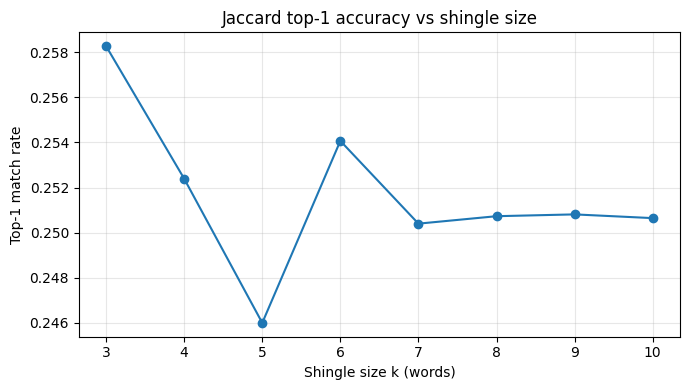

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_df["k"], sweep_df["top1"], marker="o")
ax.set_xlabel("Shingle size k (words)")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Jaccard top-1 accuracy vs shingle size")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("k_sweep.png", dpi=150)
plt.show()

## Distribution of actual rank

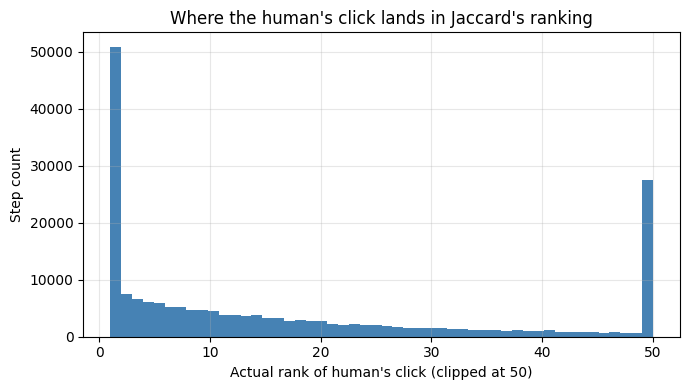

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
jaccard_eval["actual_rank"].clip(upper=50).hist(bins=50, ax=ax, color="steelblue")
ax.set_xlabel("Actual rank of human's click (clipped at 50)")
ax.set_ylabel("Step count")
ax.set_title("Where the human's click lands in Jaccard's ranking")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("rank_distribution.png", dpi=150)
plt.show()

## Top-1 accuracy by path length

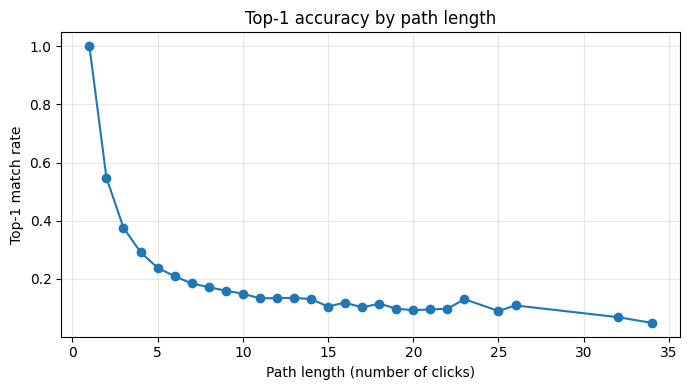

,path_length,mean,count
0,1,1.000000,797
1,2,0.547751,6848
2,3,0.376044,25614
3,4,0.292031,43040
4,5,0.238566,37499
5,6,0.209173,27972
6,7,0.184672,19180
7,8,0.171906,12088
8,9,0.159517,7460
9,10,0.149287,5399


In [ ]:
by_length = (
    jaccard_eval.groupby("path_length")["correct"]
    .agg(["mean", "count"])
    .reset_index()
)

by_length = by_length[by_length["count"] >= 100]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_length["path_length"], by_length["mean"], marker="o")
ax.set_xlabel("Path length (number of clicks)")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Top-1 accuracy by path length")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("top1_by_path_length.png", dpi=150)
plt.show()

by_length

## Top-1 accuracy by number of candidates

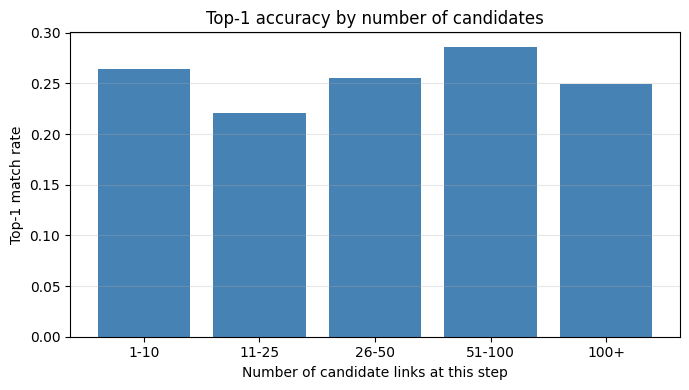

,bucket,mean,count
0,1-10,0.263788,10861
1,11-25,0.220795,42886
2,26-50,0.255095,57947
3,51-100,0.286044,48552
4,100+,0.248973,39695


In [17]:
candidate_bins = pd.cut(
    jaccard_eval["num_candidates"],
    bins=[0, 10, 25, 50, 100, jaccard_eval["num_candidates"].max() + 1],
    labels=["1-10", "11-25", "26-50", "51-100", "100+"],
)
by_candidates = (
    jaccard_eval.assign(bucket=candidate_bins)
    .groupby("bucket", observed=True)["correct"]
    .agg(["mean", "count"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_candidates["bucket"].astype(str), by_candidates["mean"], color="steelblue")
ax.set_xlabel("Number of candidate links at this step")
ax.set_ylabel("Top-1 match rate")
ax.set_title("Top-1 accuracy by number of candidates")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("top1_by_num_candidates.png", dpi=150)
plt.show()

by_candidates